In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Մեր օպտիմալացման ֆունկցիան
def f(x):
    return (1/3)*x**4 + 3*x**2 - 12*x + 10

In [36]:
# Նախնական տվյալներ
a_start, b_start = 0, 3
epsilon = 0.5
phi = 0.381966 # (3 - sqrt(5)) / 2

a, b = a_start, b_start
iterations_gs = []

# Ալգորիթմի իրականացում
while (b - a) > epsilon:
    # Ներքին կետերի հաշվարկ
    x1 = a + phi * (b - a)
    x2 = b - phi * (b - a)

    f1, f2 = f(x1), f(x2)

    # Պահպանում ենք տվյալները գրաֆիկների համար
    iterations_gs.append({
        'a': a, 'b': b,
        'x1': x1, 'x2': x2,
        'f1': f1, 'f2': f2
    })

    # Միջակայքի սեղմման տրամաբանությունը
    if f1 < f2:
        b = x2
    else:
        a = x1

print(f"2. Ոսկե հատման հաշվարկն ավարտվեց: Կատարվել է {len(iterations_gs)} իտերացիա:")
print(f"Վերջնական մոտավոր մինիմումը x* ≈ {(a + b) / 2:.4f}")

2. Ոսկե հատման հաշվարկն ավարտվեց: Կատարվել է 4 իտերացիա:
Վերջնական մոտավոր մինիմումը x* ≈ 1.3647


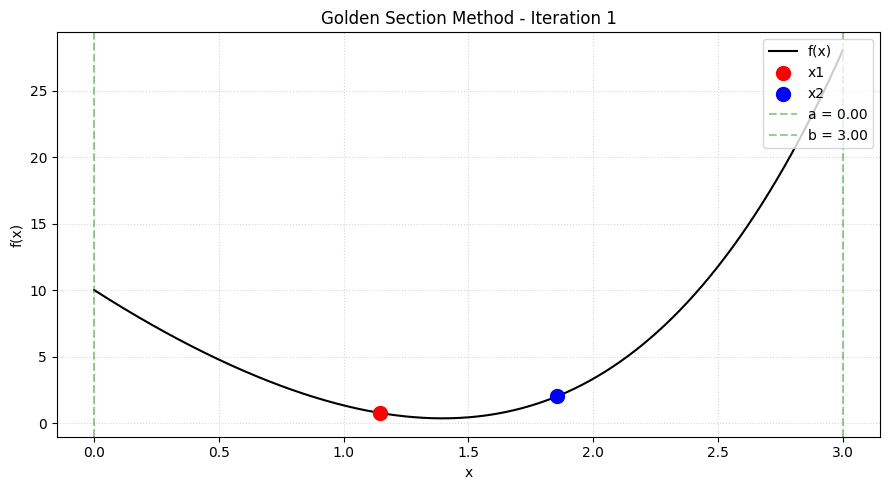

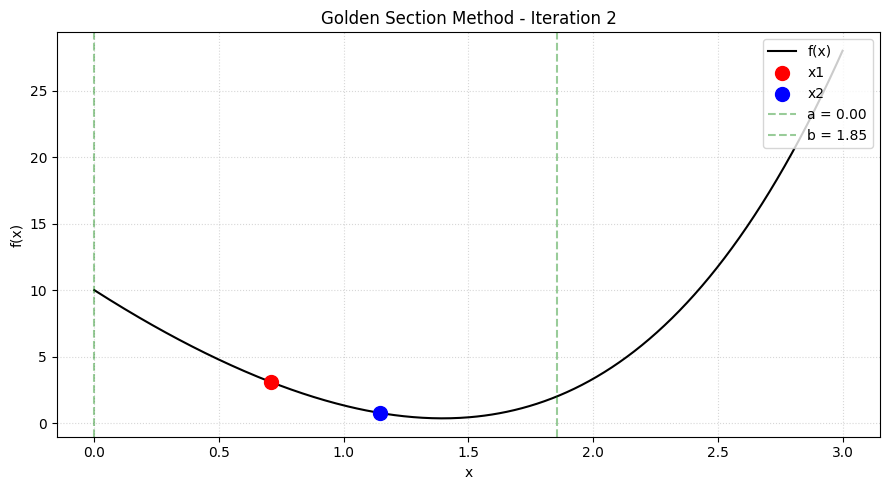

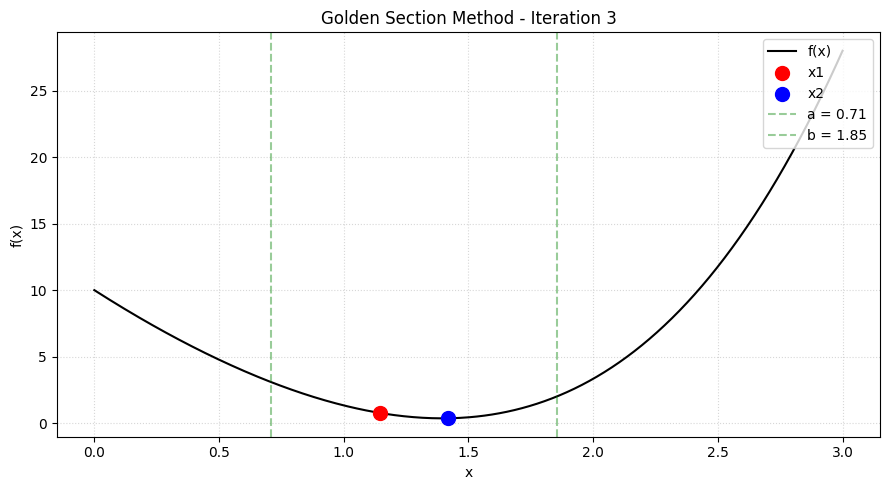

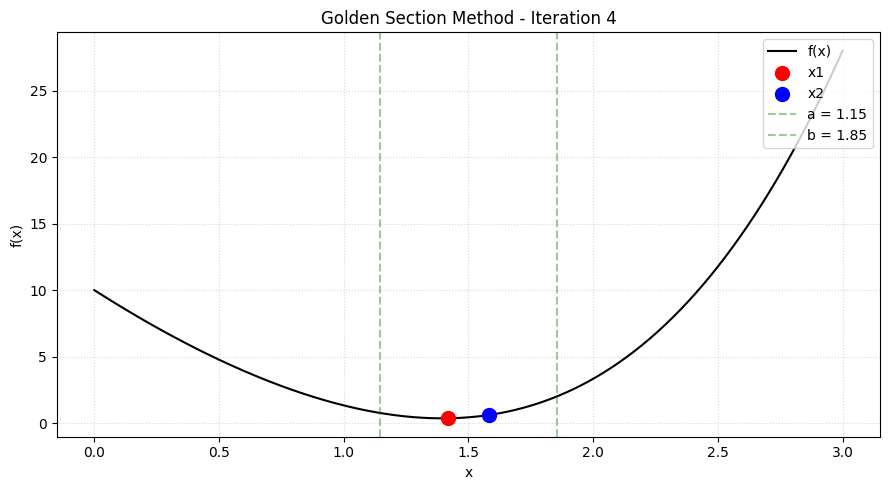

In [37]:
# Ֆունկցիայի հարթ կորի տվյալները
x_vals = np.linspace(a_start, b_start, 400)
y_vals = f(x_vals)

# Յուրաքանչյուր քայլի համար կառուցում ենք առանձին գրաֆիկ
for i, step in enumerate(iterations_gs):
    plt.figure(figsize=(9, 5))

    # Ֆունկցիայի գիծը
    plt.plot(x_vals, y_vals, color='black', label='f(x)', linewidth=1.5)

    # x1 և x2 կետերը
    plt.scatter([step['x1']], [step['f1']], color='red', s=100, label='x1', zorder=5)
    plt.scatter([step['x2']], [step['f2']], color='blue', s=100, label='x2', zorder=5)

    # Միջակայքի սահմանները (a և b)
    plt.axvline(x=step['a'], color='green', linestyle='--', alpha=0.4, label=f"a = {step['a']:.2f}")
    plt.axvline(x=step['b'], color='green', linestyle='--', alpha=0.4, label=f"b = {step['b']:.2f}")

    # Ձևավորում
    plt.title(f"Golden Section Method - Iteration {i+1}")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()